In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EconML for Causal Forests with IV
from econml.iv.dml import DMLIV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------
# Assuming the dta file is in the local directory as per the readme
file_path = r"Initial code\stata_data\data_regressions_passthrough.dta"
try:
    df = pd.read_stata(file_path)
except FileNotFoundError:
    print(f"Error: {file_path} not found. Please ensure the file is present.")
    # Creating dummy data for demonstration purposes if file is missing
    N = 10000
    df = pd.DataFrame({
        'mg_price': np.random.normal(50, 10, N),
        'ecost2': np.random.normal(10, 5, N),   # Endogenous Treatment
        'eprice': np.random.normal(8, 2, N),    # Instrument
        'temp': np.random.normal(20, 5, N),
        'windx': np.random.exponential(10, N),
        'gas': np.random.normal(15, 2, N),
        'coal': np.random.normal(40, 5, N),
        'hour': np.random.randint(1, 25, N),
        'month': np.random.randint(1, 13, N),
        'weekd': np.random.randint(1, 8, N)
    })
    # Create simple structure for demonstration
    df['ecost2'] = 0.5 * df['eprice'] + 0.3 * df['gas'] + np.random.normal(0, 1, N)
    df['mg_price'] = 0.85 * df['ecost2'] - 0.2 * df['windx'] + np.random.normal(0, 1, N)

# ---------------------------------------------------------
# 2. DATA PREPARATION
# ---------------------------------------------------------
# Define variables based on the Stata .do files
outcome_var = 'mg_price'
treatment_var = 'ecost2'
instrument_var = 'eprice'

# Covariates (Heterogeneity Drivers + Controls)
# We include all supply/demand controls + time fixed effects proxies
X_cols = ['temp', 'windx', 'gas', 'coal', 'hour', 'month', 'weekd']

# Drop missing values
df_clean = df[[outcome_var, treatment_var, instrument_var] + X_cols].dropna()

Y = df_clean[outcome_var]
T = df_clean[treatment_var]
Z = df_clean[instrument_var]
X = df_clean[X_cols]

In [2]:
# ---------------------------------------------------------
# 3. TRAIN IV-CAUSAL FOREST (DML-IV)
# ---------------------------------------------------------
# We use DMLIV which orthogonalizes the data (removes the effect of X on Y, T, and Z)
# and then estimates the heterogeneous treatment effect.
# Note: 'model_cate' (final stage) uses a Random Forest to capture non-linear heterogeneity.

est = DMLIV(
    model_y_xw=RandomForestRegressor(n_estimators=100, min_samples_leaf=10),
    model_t_xw=RandomForestRegressor(n_estimators=100, min_samples_leaf=10),
    model_t_xwz=RandomForestRegressor(n_estimators=100, min_samples_leaf=10),
    model_final=RandomForestRegressor(n_estimators=200, min_samples_leaf=10), # This is the "Causal Forest" part
    # fit_cate_intercept=False,  # <--- CRITICAL FIX: Prevents adding an extra column
    random_state=42
)

print("Training IV-Causal Forest Model...")
est.fit(Y, T, Z=Z, X=X)

Training IV-Causal Forest Model...


e:\anaconda3\envs\economics_for_challenging_times\Lib\site-packages\econml\dml\dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "



Estimated Average Pass-Through Rate: 1.2777
Compare this to the paper's benchmark of ~0.80 - 1.00


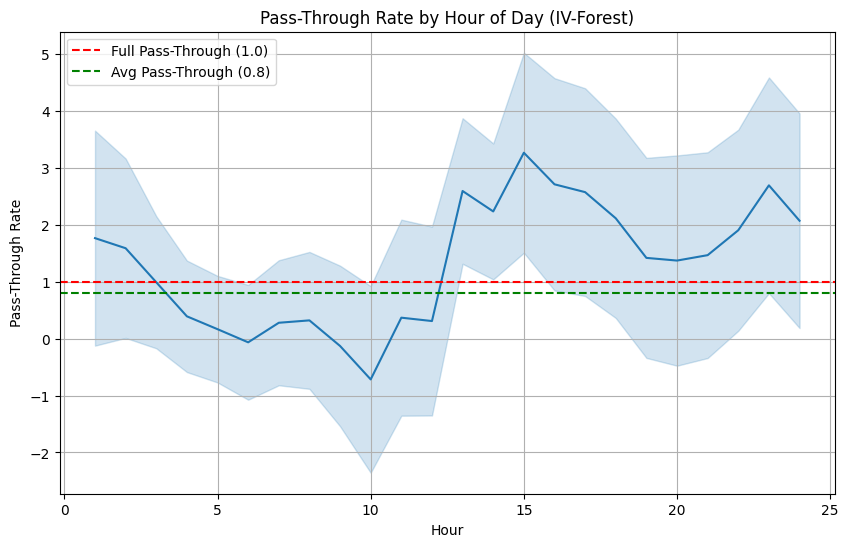

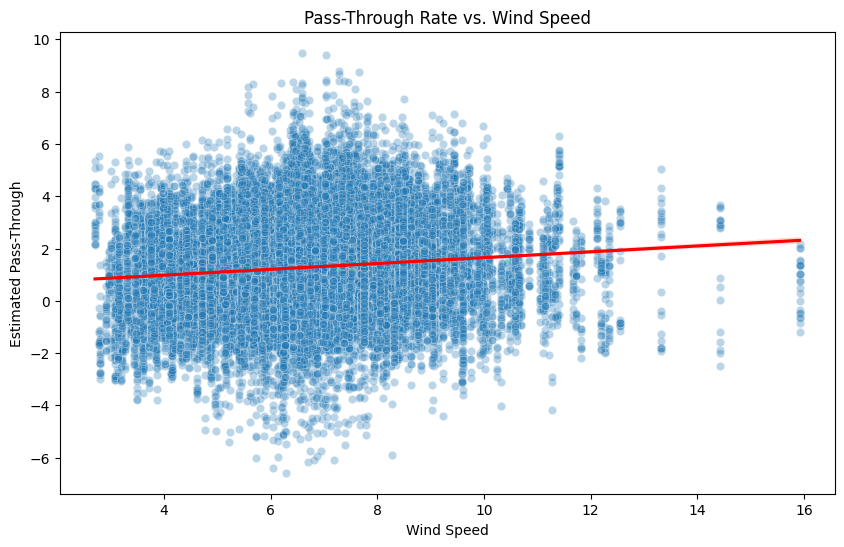

In [3]:
# ---------------------------------------------------------
# 4. RESULTS & VISUALIZATION
# ---------------------------------------------------------

# A. Average Treatment Effect (ATE)
ate = est.ate(X)
print(f"\nEstimated Average Pass-Through Rate: {ate:.4f}")
print("Compare this to the paper's benchmark of ~0.80 - 1.00")

# B. Heterogeneity by Hour (Replicating Peak vs Off-Peak)
# Predict individual treatment effects (CATE)
cate_pred = est.effect(X)
df_results = df_clean.copy()
df_results['CATE'] = cate_pred

# Plot CATE by Hour of Day
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results, x='hour', y='CATE', errorbar='sd')
plt.axhline(y=1.0, color='r', linestyle='--', label='Full Pass-Through (1.0)')
plt.axhline(y=0.8, color='g', linestyle='--', label='Avg Pass-Through (0.8)')
plt.title('Pass-Through Rate by Hour of Day (IV-Forest)')
plt.ylabel('Pass-Through Rate')
plt.xlabel('Hour')
plt.legend()
plt.grid(True)
plt.show()

# C. Heterogeneity by Wind Speed (New Insight)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_results, x='windx', y='CATE', alpha=0.3)
sns.regplot(data=df_results, x='windx', y='CATE', scatter=False, color='red')
plt.title('Pass-Through Rate vs. Wind Speed')
plt.xlabel('Wind Speed')
plt.ylabel('Estimated Pass-Through')
plt.show()

In [4]:
# ---------------------------------------------------------
# 5. FEATURE IMPORTANCE (What drives the heterogeneity?)
# ---------------------------------------------------------
# Which variables cause the pass-through to change the most?
try:
    # Feature importance of the final CATE model
    importance = est.model_cate.feature_importances_
    print(importance)
    print(est.cate_feature_names())
    print(X_cols)
    feat_imp = pd.Series(importance, index=X_cols).sort_values(ascending=False)
    
    plt.figure(figsize=(8, 5))
    feat_imp.plot(kind='bar')
    plt.title('Drivers of Pass-Through Heterogeneity')
    plt.ylabel('Importance')
    plt.show()
except AttributeError:
    print("Feature importance not directly available for this CATE estimator wrapper.")

[0.07953671 0.13444525 0.11589825 0.12597773 0.08919647 0.19232359
 0.12669052 0.13593148]
['temp', 'windx', 'gas', 'coal', 'hour', 'month', 'weekd']
['temp', 'windx', 'gas', 'coal', 'hour', 'month', 'weekd']


ValueError: Length of values (8) does not match length of index (7)

In [ ]:
est.summary()

In [ ]:
# --- 0) Install dependencies (run once) ---
# !pip install -q econml pandas numpy scikit-learn matplotlib statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

from econml.iv.dml import NonParamDMLIV
from econml.grf import RegressionForest

# --- 1) Load data ---
# Update the path to wherever you store the Stata file
df = pd.read_stata(r"Initial code\stata_data\data_regressions_passthrough.dta")

# --- 2) Core variables (names follow the Stata do-file macros) ---
Y_col = "mg_price"   # outcome p_th
T_col = "ecost2"     # treatment tau_t * e_th (marginal emissions cost)
Z_col = "eprice"     # instrument tau_t (permit price)

# --- 3) Basic cleaning ---
needed = [Y_col, T_col, Z_col]
df = df.dropna(subset=needed).copy()

# Peak definition used in the paper: 8am to 8pm (inclusive) for peak hours
if "hour" in df.columns:
    df["peak"] = ((df["hour"] >= 8) & (df["hour"] <= 20)).astype(int)
else:
    df["peak"] = 0  # fallback; ideally hour exists

# --- 4) Choose heterogeneity features X and controls W ---
# Adjust if your dataset uses slightly different names.
X_cols = []
for c in ["peak", "windx", "coal", "gas", "brent"]:
    if c in df.columns:
        X_cols.append(c)

# If you have an explicit demand/load variable, add it here:
for demand_cand in ["demand", "load", "quantity", "mg_qty"]:
    if demand_cand in df.columns:
        X_cols.append(demand_cand)
        break

# Controls: follow the paper's main controls (weather + wind + fuel) + fixed effects
W_num_cols = [c for c in ["temp", "tempx", "humid", "windx", "windx2", "coal", "gas", "brent"] if c in df.columns]

# Fixed effects / categorical controls used by the paper's baseline:
W_cat_cols = []
for c in ["hour", "weekd", "month", "year", "ym"]:
    if c in df.columns:
        W_cat_cols.append(c)

# --- 5) Grouping for cross-fitting (avoid leakage across hours of same day) ---
# Try common date columns; adjust as needed once you inspect your df columns.
group_col = None
for c in ["date", "day", "ymd", "t", "day_id"]:
    if c in df.columns:
        group_col = c
        break

if group_col is None:
    # fallback: group by (year, month, day-of-month) if those exist
    if all(c in df.columns for c in ["year", "month", "day"]):
        df["__group_day__"] = df["year"].astype(int)*10000 + df["month"].astype(int)*100 + df["day"].astype(int)
        group_col = "__group_day__"
    else:
        # last resort: no grouping (not recommended)
        df["__group_day__"] = np.arange(len(df))
        group_col = "__group_day__"

groups = df[group_col].values
cv = GroupKFold(n_splits=5)

# --- 6) Preprocess X and W ---
# We'll preprocess numerics with scaling and categoricals with one-hot.
X_num = [c for c in X_cols if df[c].dtype.kind in "if" and c != "peak"]
X_bin = [c for c in X_cols if c == "peak"]

preprocess_X = ColumnTransformer(
    transformers=[
        ("xnum", StandardScaler(), X_num),
        ("xbin", "passthrough", X_bin)
    ],
    remainder="drop"
)

preprocess_W = ColumnTransformer(
    transformers=[
        ("wnum", StandardScaler(), W_num_cols),
        ("wcat", OneHotEncoder(drop="first", handle_unknown="ignore"), W_cat_cols)
    ],
    remainder="drop"
)

X = preprocess_X.fit_transform(df)
W = preprocess_W.fit_transform(df)

Y = df[Y_col].values
T = df[T_col].values
Z = df[Z_col].values

# --- 7) Specify nuisance models and the forest final stage ---
# Nuisance models can be flexible but not too huge; tune as needed.
model_y_xw = RandomForestRegressor(
    n_estimators=400, min_samples_leaf=50, random_state=123, n_jobs=-1
)
model_t_xw = RandomForestRegressor(
    n_estimators=400, min_samples_leaf=50, random_state=123, n_jobs=-1
)
model_t_xwz = RandomForestRegressor(
    n_estimators=600, min_samples_leaf=50, random_state=123, n_jobs=-1
)

# Forest for heterogeneous IV effect theta(X): this is the "causal forest" piece
model_final = RegressionForest(
    n_estimators=2000,
    min_samples_leaf=20,
    honest=True,              # honesty helps reduce bias in CATE
    max_samples=0.7,         # enables meaningful OOB predictions
    random_state=123,
    n_jobs=-1
)

est = NonParamDMLIV(
    model_y_xw=model_y_xw,
    model_t_xw=model_t_xw,
    model_t_xwz=model_t_xwz,
    model_final=model_final,
    cv=cv,
    random_state=123
)
print(Y.shape, T.shape, Z.shape, X.shape, W.shape, groups.shape)
print(Y.ndim, T.ndim, Z.ndim, X.ndim, W.ndim, groups.ndim)
# --- 8) Fit (with groups for GroupKFold) ---
est.fit(Y, T, Z=Z, X=X, W=W, groups=groups)

# --- 9) CATE = heterogeneous pass-through rho(X): effect of +1 unit of emissions cost ---
cate = est.effect(X, T0=0, T1=1)  # per €1/MWh marginal emissions cost

print("ATE (mean of CATE):", np.mean(cate))
print("CATE percentiles:", np.percentile(cate, [5, 25, 50, 75, 95]))

# --- 10) Visualization: CATE vs a driver (example: windx) ---
def plot_cate_vs_raw(feature_name, raw_series, cate_values, n_bins=20):
    # bin raw feature and plot mean CATE in bins
    s = pd.Series(raw_series).astype(float)
    q = np.linspace(0, 1, n_bins+1)
    edges = s.quantile(q).values
    # ensure unique edges
    edges = np.unique(edges)
    if len(edges) <= 2:
        print(f"Not enough variation to bin {feature_name}.")
        return

    bin_id = np.digitize(s, edges[1:-1], right=True)
    bin_means_x = []
    bin_means_tau = []
    for b in np.unique(bin_id):
        mask = bin_id == b
        bin_means_x.append(s[mask].mean())
        bin_means_tau.append(np.mean(cate_values[mask]))

    plt.figure()
    plt.plot(bin_means_x, bin_means_tau, marker="o")
    plt.xlabel(feature_name)
    plt.ylabel("Estimated pass-through (CATE)")
    plt.title(f"CATE vs {feature_name}")
    plt.show()

# Example plots if columns exist:
if "windx" in df.columns:
    plot_cate_vs_raw("windx", df["windx"].values, cate)

if "coal" in df.columns:
    plot_cate_vs_raw("coal", df["coal"].values, cate)

if "gas" in df.columns:
    plot_cate_vs_raw("gas", df["gas"].values, cate)

# --- 11) Peak vs off-peak comparison (robustness to Table 3.2 logic) ---
if "peak" in df.columns:
    print("Mean CATE peak:", np.mean(cate[df["peak"].values == 1]))
    print("Mean CATE off-peak:", np.mean(cate[df["peak"].values == 0]))


(26050,) (26050,) (26050,) (26050, 5) (26050, 92) (26050,)
1 1 1 2 2 1


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

In [ ]:
import pandas as pd
import numpy as np
from scipy import sparse

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

from econml.iv.dml import NonParamDMLIV
from econml.grf import RegressionForest

# ---- Load ----
df = pd.read_stata(r"Initial code\stata_data\data_regressions_passthrough.dta").dropna(
    subset=["mg_price", "ecost2", "eprice"]
).copy()

# ---- Group by day to avoid leakage across the same permit-price shock ----
df["day_id"] = df["year"].astype(int)*10000 + df["month"].astype(int)*100 + df["day"].astype(int)
groups = df["day_id"].values
cv = GroupKFold(n_splits=5)

# ---- Define objects ----
Y = df["mg_price"].to_numpy()                 # (n,)
T = df["ecost2"].to_numpy()                   # (n,)
Z = df["eprice"].to_numpy().reshape(-1, 1)    # (n, 1)  <-- IMPORTANT

# ---- Features ----
X_cols = ["peak", "windx", "coal", "gas", "brent", "temp", "humid"]  # heterogeneity drivers
W_num_cols = ["temp", "tempx", "humid", "windx", "windx2", "coal", "gas", "brent"]  # controls
W_cat_cols = ["hour", "weekd", "ym"]  # fixed effects-ish controls

# ---- Preprocess (FORCE DENSE OUTPUT!) ----
preprocess_X = ColumnTransformer(
    transformers=[
        ("xnum", StandardScaler(), [c for c in X_cols if c != "peak"]),
        ("xbin", "passthrough", ["peak"]),
    ],
    remainder="drop",
    sparse_threshold=0.0,   # <-- forces dense output if possible
)

preprocess_W = ColumnTransformer(
    transformers=[
        ("wnum", StandardScaler(), W_num_cols),
        ("wcat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), W_cat_cols),
    ],
    remainder="drop",
    sparse_threshold=0.0,   # <-- forces dense output
)

X = preprocess_X.fit_transform(df)
W = preprocess_W.fit_transform(df)

# Extra safety: densify if anything still sparse
if sparse.issparse(X): X = X.toarray()
if sparse.issparse(W): W = W.toarray()

# ---- Models ----
model_y_xw  = RandomForestRegressor(n_estimators=300, min_samples_leaf=80, random_state=123, n_jobs=-1)
model_t_xw  = RandomForestRegressor(n_estimators=300, min_samples_leaf=80, random_state=123, n_jobs=-1)
model_t_xwz = RandomForestRegressor(n_estimators=400, min_samples_leaf=80, random_state=123, n_jobs=-1)

# econml 0.16 uses max_samples (not subsample_fr)
model_final = RegressionForest(
    n_estimators=800,
    min_samples_leaf=50,
    honest=True,
    max_samples=0.7,
    inference=False,
    random_state=123,
    n_jobs=-1
)

est = NonParamDMLIV(
    model_y_xw=model_y_xw,
    model_t_xw=model_t_xw,
    model_t_xwz=model_t_xwz,
    model_final=model_final,
    cv=cv,
    random_state=123
)

# ---- Fit ----
est.fit(Y, T, Z=Z, X=X, W=W, groups=groups)

# ---- CATE ----
cate = est.effect(X, T0=0, T1=1)  # pass-through per +1 unit emissions cost
print("ATE (mean CATE):", cate.mean())
print("CATE percentiles:", np.percentile(cate, [5, 25, 50, 75, 95]))


ATE (mean CATE): 0.43137654121323726
CATE percentiles: [-5.83234078 -1.15656474  0.72887335  2.14597339  5.5945105 ]


In [ ]:
# Get orthogonalized residual components
y_res, t_res, X_res, W_res, Z_res = est.residuals_  # (Y - E[Y|X,W],  E[T|X,W,Z]-E[T|X,W], ...)

# OOB CATE predictions from the final forest
tau_oob = est.model_final_.oob_predict(X_res)

# Weighted loss implied by the DMLIV objective
pseudo = y_res / t_res
weights = t_res**2
oob_rloss = np.average((pseudo - tau_oob)**2, weights=weights)

print("OOB weighted R-loss:", oob_rloss)


AttributeError: `fit` was called with `cache_values=False`. Set to `True` to enable residual storage.

In [ ]:
import statsmodels.api as sm

y_res, t_res, X_res, _, _ = est.residuals_
tau_oob = est.model_final_.oob_predict(X_res)

X_blp = sm.add_constant(t_res * tau_oob)
blp = sm.WLS(y_res, X_blp, weights=t_res**2).fit(cov_type="HC1")
print(blp.summary())


AttributeError: `fit` was called with `cache_values=False`. Set to `True` to enable residual storage.

Training Instrumental Forest...


e:\anaconda3\envs\economics_for_challenging_times\Lib\site-packages\econml\dml\dml.py:192: UserWarning: The final model has a nonzero intercept for at least one outcome; it will be subtracted, but consider fitting a model without an intercept if possible.
  warn("The final model has a nonzero intercept for at least one outcome; "


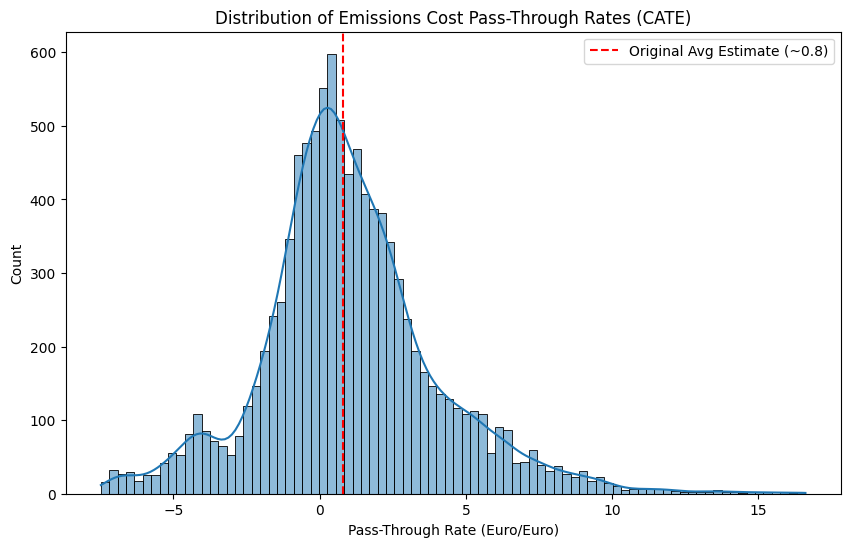

is_peak
0    1.176696
1    0.840656
Name: cate_passthrough, dtype: float64


In [3]:
import pandas as pd
import numpy as np
from econml.iv.dml import DMLIV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Load and Prep Data
# Assuming you have loaded the .dta file into a pandas DataFrame 'df'
# df = pd.read_stata("stata_data/data_regressions_passthrough.dta")
df = pd.read_stata(r"Initial code\stata_data\data_regressions_passthrough.dta").dropna()

# Filter as per Stata code
df = df[df['rd'] != 1].copy()

# 2. Define Variables
Y = df['mg_price']                  # Outcome
T = df['ecost2']                    # Treatment (Marginal emissions cost)
Z = df['eprice']                    # Instrument (Emissions price)

# Construct Feature Matrix X (Heterogeneity drivers)
# We include weather, fuel costs, and time dummies
X_cols = ['temp', 'tempx', 'humid', 'windx', 'windx2', 
          'coal', 'gas', 'brent', 
          'hour', 'month', 'year', 'weekd']

# Ensure categoricals are numeric for the forest
X = df[X_cols].copy()
X = pd.get_dummies(X, columns=['year', 'month', 'weekd'], drop_first=True)
# Keep 'hour' numeric to allow splits like "hour > 8" (peak vs off-peak)

# 3. Configure the Instrumental Causal Forest (DMLIV)
# We use Random Forests for the nuisance models (predicting Y, T, Z from X)
# and a Random Forest for the final CATE model to allow non-linear heterogeneity.

est = DMLIV(
    model_y_xw=RandomForestRegressor(n_estimators=100, min_samples_leaf=20, random_state=42),
    model_t_xw=RandomForestRegressor(n_estimators=100, min_samples_leaf=20, random_state=42),
    model_t_xwz=RandomForestRegressor(n_estimators=100, min_samples_leaf=20, random_state=42),
    model_final=RandomForestRegressor(n_estimators=200, min_samples_leaf=10, random_state=42),
    discrete_treatment=False,
    discrete_instrument=False
)

# 4. Train the Model
# This performs the "Double" orthogonalization:
# Residualizes Y, T, and Z on X, then estimates the causal effect using the residuals.
print("Training Instrumental Forest...")
est.fit(Y, T, Z=Z, X=X)

# 5. Estimate Treatment Effects
# const_marginal_effect gives the CATE (Conditional Average Treatment Effect)
cate_pred = est.const_marginal_effect(X)

# Add results back to dataframe for analysis
df['cate_passthrough'] = cate_pred

# 6. Visualize Heterogeneity
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['cate_passthrough'], kde=True)
plt.axvline(x=0.8, color='r', linestyle='--', label='Original Avg Estimate (~0.8)')
plt.title("Distribution of Emissions Cost Pass-Through Rates (CATE)")
plt.xlabel("Pass-Through Rate (Euro/Euro)")
plt.legend()
plt.show()

# 7. Inspect Drivers of Heterogeneity (e.g., Peak vs Off-Peak)
# Replicating the "Peak" finding
df['is_peak'] = df['hour'].apply(lambda h: 1 if 8 <= h <= 20 else 0)
print(df.groupby('is_peak')['cate_passthrough'].mean())

In [4]:
df['cate_passthrough'].mean()

np.float64(1.0249605852553187)